In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
data = pd.read_csv("CollegePlacement.csv")

In [3]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
data.tail()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No
9999,CLG0060,109,9.41,9.77,8,No,3,5,5,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [6]:
data.shape

(10000, 10)

In [7]:
data.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [8]:
cgpa_above_10 = data[data["CGPA"] > 10].shape[0]
print("Number of students with CGPA more than 10:", cgpa_above_10)

Number of students with CGPA more than 10: 249


In [9]:
data.drop(data[data["CGPA"] > 10].index, inplace=True)

In [10]:
data.shape

(9751, 10)

In [11]:
data.drop(columns=["College_ID"], inplace=True)

In [12]:
data.shape

(9751, 9)

In [13]:
data.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,9751.000000,9751.000000,9751.000000,9751.000000,9751.000000,9751.000000,9751.000000
mean,99.479438,7.476841,7.465179,5.546200,4.967798,5.563737,2.509896
std,15.069030,1.417550,1.426456,2.870628,3.161108,2.900506,1.715773
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.250000,6.260000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.500000,7.490000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.700000,8.690000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000


In [14]:
data.isnull().sum()

IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [15]:
data.duplicated().sum()

0

In [16]:
y=data.Placement
X=data.drop(columns=['Placement'])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

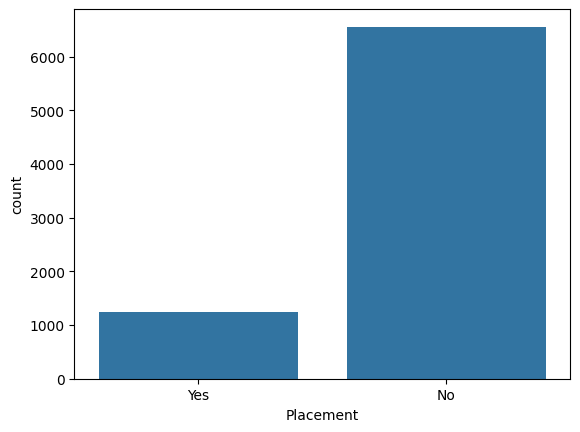

In [18]:
sns.countplot(x=y_train)
plt.show()

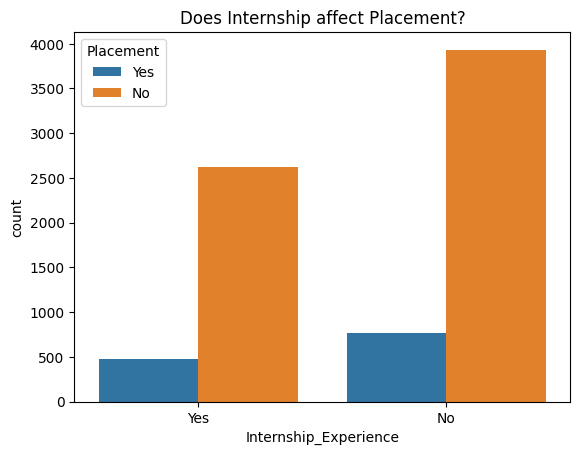

In [19]:
train_combined = pd.concat([X_train[['Internship_Experience']], y_train], axis=1)
sns.countplot(x="Internship_Experience", hue="Placement", data=train_combined)
plt.title("Does Internship affect Placement?")
plt.show()

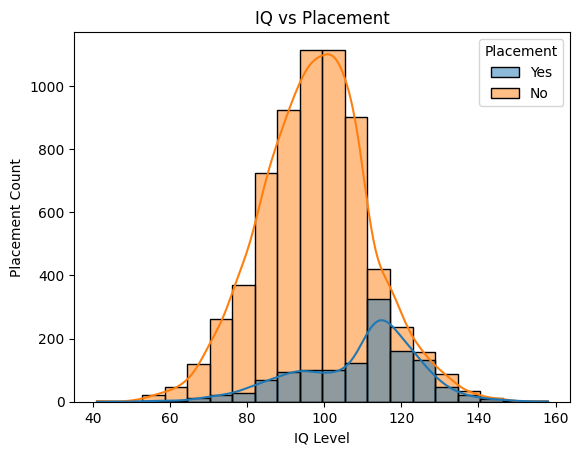

In [20]:
bins = [20, 40, 60, 80, 90, 100, 120, 140, 160]
train_combined = pd.concat([X_train[['IQ']], y_train], axis=1)
sns.histplot(data=train_combined, x='IQ', hue='Placement', bins=20, kde=True, edgecolor='black')
plt.title("IQ vs Placement")
plt.xlabel("IQ Level")
plt.ylabel("Placement Count")
plt.show()

<Axes: xlabel='CGPA', ylabel='IQ'>

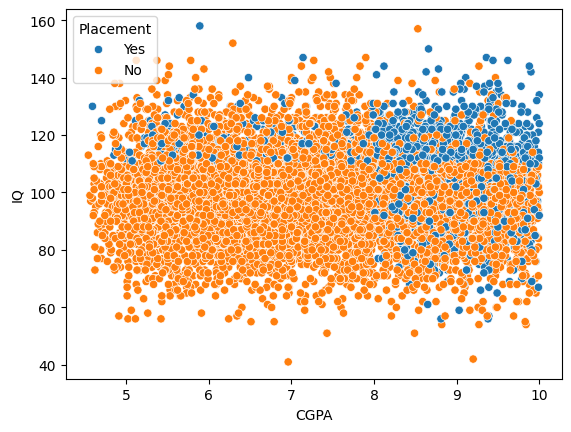

In [21]:
train_combined = pd.concat([X_train[['CGPA','IQ']], y_train], axis=1)
sns.scatterplot(data=train_combined, x='CGPA', y='IQ', hue='Placement')

In [22]:
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined.drop(train_combined[(train_combined['CGPA'] < 6) &
                    (train_combined['Placement'] == 'Yes')].index, inplace=True)
X_train = train_combined.drop(columns=['Placement'])
y_train = train_combined['Placement']

In [23]:
y_train=pd.Series(y_train, name="Placement", index=X_train.index)

<Axes: xlabel='CGPA', ylabel='Communication_Skills'>

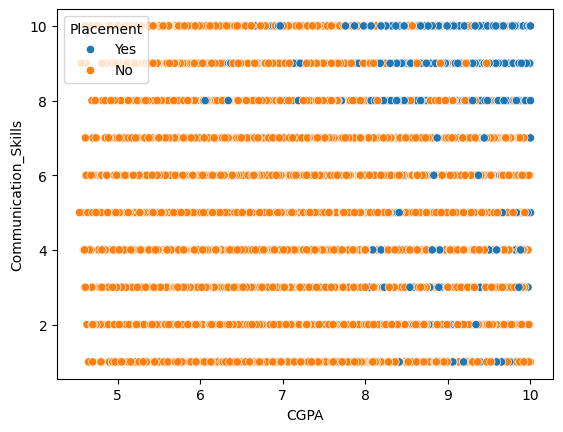

In [24]:
train_combined = pd.concat([X_train[['Communication_Skills','CGPA']],y_train], axis=1)
sns.scatterplot(data=train_combined, x='CGPA', y='Communication_Skills', hue='Placement')

In [25]:
le = LabelEncoder()
X_train["Internship_Experience"] = le.fit_transform(X_train["Internship_Experience"])
X_test["Internship_Experience"] = le.fit_transform(X_test["Internship_Experience"])
y_train = le.fit_transform(y_train)

In [26]:
y_test = le.fit_transform(y_test)

In [27]:
X_train.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
7964,91,9.22,8.84,9,1,9,8,3
4914,80,5.53,5.23,8,0,1,6,5
4754,91,6.48,6.30,4,0,1,10,0
8806,86,7.76,7.44,10,1,9,1,2
8998,89,9.71,9.72,1,0,5,7,5


In [28]:
y_train=pd.Series(y_train, name="Placement", index=X_train.index)

In [29]:
y_train.head()

7964    1
4914    0
4754    0
8806    0
8998    0
Name: Placement, dtype: int32

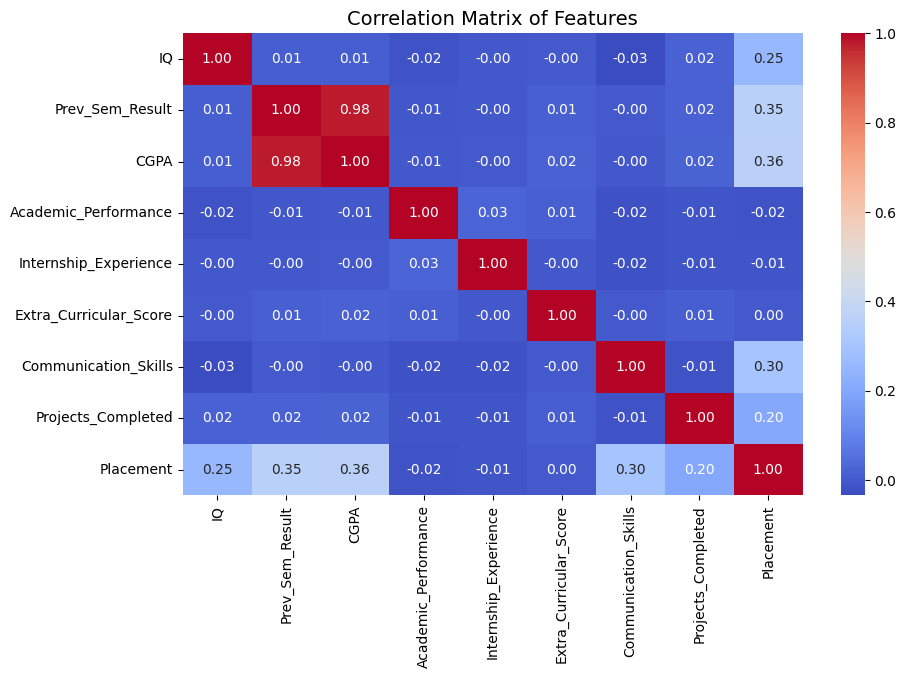

In [30]:
plt.figure(figsize=(10,6))
train_combined = pd.concat([X_train, y_train], axis=1)
corr = train_combined.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features", fontsize=14)
plt.show()

In [31]:
X_train.drop(columns=['Prev_Sem_Result'],inplace=True )
X_test.drop(columns=['Prev_Sem_Result'],inplace=True)

In [32]:
X_train.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
7964,91,8.84,9,1,9,8,3
4914,80,5.23,8,0,1,6,5
4754,91,6.30,4,0,1,10,0
8806,86,7.44,10,1,9,1,2
8998,89,9.72,1,0,5,7,5


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [35]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [36]:
print("=== Support Vector Machine (RBF) ===")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

=== Support Vector Machine (RBF) ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1621
           1       0.91      0.79      0.84       330

    accuracy                           0.95      1951
   macro avg       0.93      0.89      0.91      1951
weighted avg       0.95      0.95      0.95      1951

Accuracy: 0.9502819067145054
Precision: 0.9059233449477352
Recall: 0.7878787878787878
F1 Score: 0.8427876823338736
ROC-AUC: 0.983547380031032


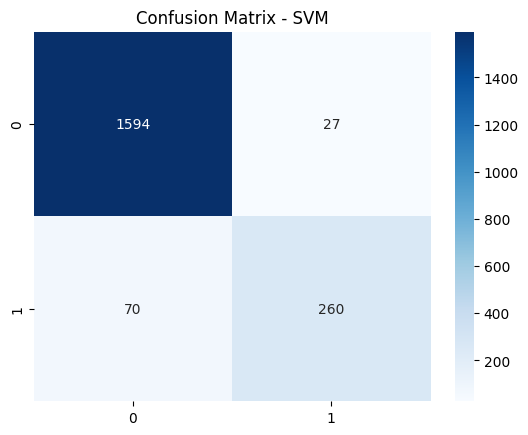

In [37]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

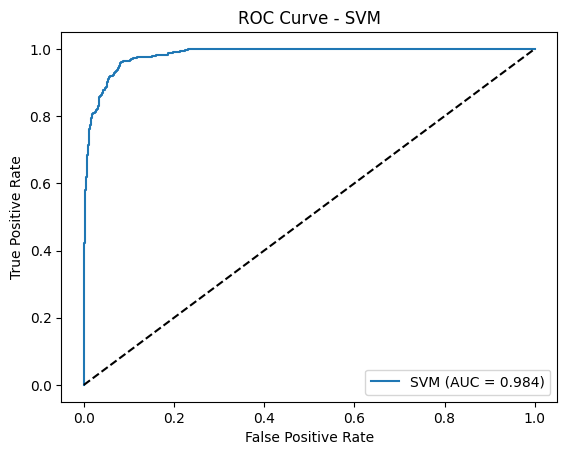

In [38]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr, tpr, label="SVM (AUC = %.3f)" % roc_auc_score(y_test, y_prob_svm))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [39]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [40]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [41]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1621
           1       1.00      0.98      0.99       330

    accuracy                           1.00      1951
   macro avg       1.00      0.99      0.99      1951
weighted avg       1.00      1.00      1.00      1951

Accuracy: 0.9964120963608406
Precision: 1.0
Recall: 0.9787878787878788
F1 Score: 0.9892802450229708
ROC-AUC: 1.0


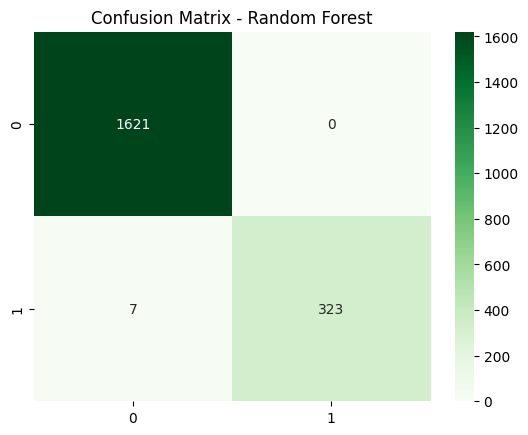

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

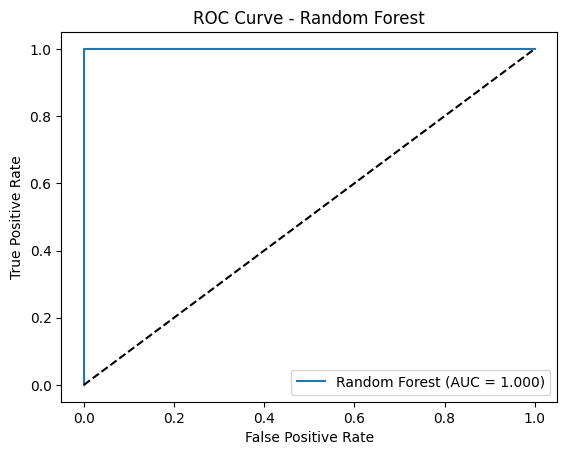

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest (AUC = %.3f)" % roc_auc_score(y_test, y_prob_rf))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [44]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [45]:
y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

In [46]:
print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1621
           1       1.00      1.00      1.00       330

    accuracy                           1.00      1951
   macro avg       1.00      1.00      1.00      1951
weighted avg       1.00      1.00      1.00      1951

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


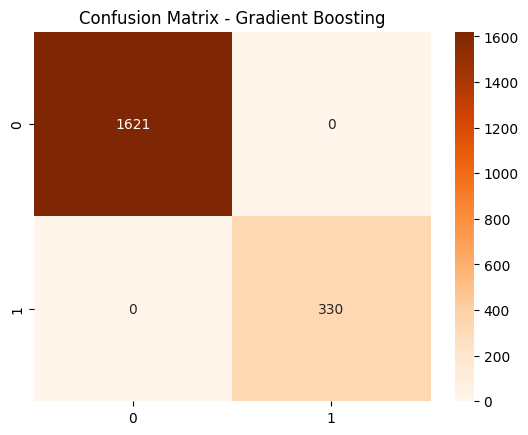

In [47]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

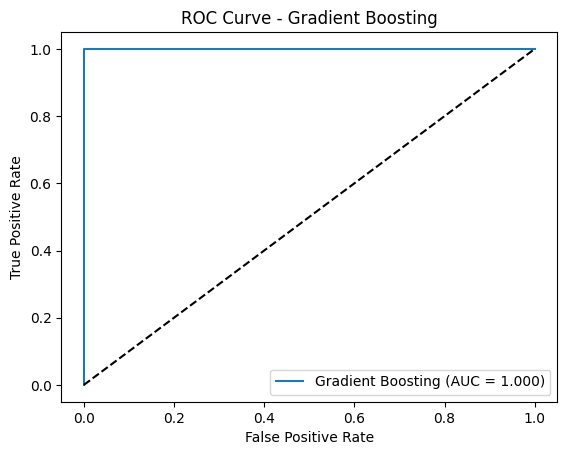

In [48]:
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr, tpr, label="Gradient Boosting (AUC = %.3f)" % roc_auc_score(y_test, y_prob_gb))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

In [49]:
new_candidate = pd.DataFrame({
    'IQ': [70],
    'CGPA': [8.5],
    'Academic_Performance': [8],
    'Internship_Experience': [0],
    'Extra_Curricular_Score': [7.5],
    'Communication_Skills': [7.0],
    'Projects_Completed': [3]
})

In [50]:
new_candidate_scaled = scaler.transform(new_candidate)

In [51]:
svm_pred = svm_model.predict(new_candidate_scaled)
svm_prob = svm_model.predict_proba(new_candidate_scaled)
svm_pred_prob = svm_prob[0, svm_pred[0]] 

print("SVM Prediction:", svm_pred[0])
print("SVM Probability:", svm_pred_prob)

SVM Prediction: 0
SVM Probability: 0.8375064890641659


In [52]:
rf_pred = rf_model.predict(new_candidate_scaled)
rf_prob = rf_model.predict_proba(new_candidate_scaled)
rf_pred_prob = rf_prob[0, rf_pred[0]] 

print("Random Forrest Prediction:", rf_pred[0])
print("Random Forrest Probability:", rf_pred_prob)

Random Forrest Prediction: 0
Random Forrest Probability: 0.985


In [53]:
gb_pred = gb_model.predict(new_candidate_scaled)
gb_prob = gb_model.predict_proba(new_candidate_scaled)
gb_pred_prob = gb_prob[0, gb_pred[0]] 

print("Gradient Boosting Prediction:", gb_pred[0])
print("Gradient Boosting Probability:", gb_pred_prob)

Gradient Boosting Prediction: 0
Gradient Boosting Probability: 0.9975826766685664


In [54]:
import joblib
joblib.dump(gb_model, "gradient_boosting_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
